## Backtrader example 2
In this file we follow the following steps:
- Installing libraries
- Importing
- Fetching data, parsing  
- Initialization and feeding data to  Backtrader's data format
- Define strategy (RSI crossover)
- Run backtesting
- Print Strategy Performance Metrics
- Plotting 

### Installing necessary libraries

In [408]:
# %pip install backtrader

# %pip install matplotlib

# pip install ipympl

### Importing

In [409]:
import backtrader as bt
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
# %matplotlib widget
%matplotlib inline

### Fetching data, parsing

In [410]:
fxdata = yf.download('AAPL',start='2010-01-01',end='2024-12-30')
fxdata

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.440331,6.455077,6.391278,6.422877,493729600
2010-01-05,6.451465,6.487878,6.417459,6.458086,601904800
2010-01-06,6.348847,6.477046,6.342227,6.451467,552160000
2010-01-07,6.337108,6.379841,6.291065,6.372318,477131200
2010-01-08,6.379241,6.379843,6.291368,6.328684,447610800
...,...,...,...,...,...
2024-12-20,254.210510,254.719945,245.420172,247.767582,147495300
2024-12-23,254.989655,255.369227,253.171646,254.490204,40858800


In [411]:
# cols = ['Dividends','Stock Splits']   
# (fxdata[cols] == 0).all()
# fxdata.drop(columns= cols, inplace = True)
# fxdata

In [412]:
fxdata = pd.DataFrame(fxdata)
fxdata.index = pd.to_datetime(fxdata.index)
fxdata

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.440331,6.455077,6.391278,6.422877,493729600
2010-01-05,6.451465,6.487878,6.417459,6.458086,601904800
2010-01-06,6.348847,6.477046,6.342227,6.451467,552160000
2010-01-07,6.337108,6.379841,6.291065,6.372318,477131200
2010-01-08,6.379241,6.379843,6.291368,6.328684,447610800
...,...,...,...,...,...
2024-12-20,254.210510,254.719945,245.420172,247.767582,147495300
2024-12-23,254.989655,255.369227,253.171646,254.490204,40858800


In [413]:
# Flatten the MultiIndex columns
# Extract only the 'Price' level and rename to standard Backtrader column names
fxdata.columns = [col[0] for col in fxdata.columns]  # Takes 'Close', 'High', 'Low', 'Open', 'Volume'
fxdata

,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,6.440331,6.455077,6.391278,6.422877,493729600
2010-01-05,6.451465,6.487878,6.417459,6.458086,601904800
2010-01-06,6.348847,6.477046,6.342227,6.451467,552160000
2010-01-07,6.337108,6.379841,6.291065,6.372318,477131200
2010-01-08,6.379241,6.379843,6.291368,6.328684,447610800
...,...,...,...,...,...
2024-12-20,254.210510,254.719945,245.420172,247.767582,147495300
2024-12-23,254.989655,255.369227,253.171646,254.490204,40858800
2024-12-24,257.916443,257.926411,255.009620,255.209412,23234700


### Initialization and feeding data to  Backtrader's data format

In [414]:
# Initialize Cerebro
cerebro = bt.Cerebro()

In [415]:
# Parse/Convert to Backtrader's PandasData format
data = bt.feeds.PandasData(dataname=fxdata,
                           datetime=None,
                           open=3,
                           high=1,
                           low=2,
                           close=1,
                           volume=4,
                           )

### Define strategy (RSI crossover)

In [416]:
# Define strategy
class RSIStrategy(bt.Strategy):
    def __init__(self):
        self.rsi = bt.indicators.RSI(self.data.close, period=14)

    def next(self):
        if not self.position:
            if self.rsi < 30:
                self.buy()
                print(f"Buy at {self.data.close[0]}")
        elif self.rsi > 70:
            self.sell()
            print(f"Sell at {self.data.close[0]}")

In [417]:
# Add strategy and data
cerebro.addstrategy(RSIStrategy)
cerebro.adddata(data)
cerebro.broker.setcash(10000)

In [418]:
# Add analyzers for performance metrics
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')  # Sharpe Ratio
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')     # Total and annual returns
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')   # Drawdown stats
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades') # Trade statistics

### Run backtesting

In [419]:
# Run the backtest
results = cerebro.run()
strat = results[0]  # Get the first (and only) strategy instance


Buy at 9.560735644196138
Sell at 10.773511011120991
Buy at 18.192916229281522
Sell at 14.052758004439616
Buy at 16.02863366344178
Sell at 17.84661766092003
Buy at 26.3954632715135
Sell at 27.819290854009132
Buy at 24.777795140586075
Sell at 24.18207446139833
Buy at 22.453323376583054
Sell at 23.926529400549473
Buy at 24.933605481786923
Sell at 27.14688808407688
Buy at 38.51061364118392
Sell at 44.28088339823529
Buy at 47.031494997541834
Sell at 43.75743378437187
Buy at 42.78373529332015
Sell at 50.651778020354186
Buy at 69.4061923618355
Sell at 77.14965158521665
Buy at 151.66253001815127
Sell at 161.25750343998283
Buy at 178.71706628147237
Sell at 186.98736499365313
Buy at 176.0686126971914
Sell at 190.45989075478766


### Print Strategy Performance Metrics

In [420]:
# Extract and print performance metrics
print("=== Strategy Performance ===")

# Starting and Final Portfolio Value
start_value = cerebro.broker.startingcash
final_value = cerebro.broker.getvalue()
print(f"Starting Portfolio Value: ${start_value:.2f}")
print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Profit/Loss: ${(final_value - start_value):.2f}")

=== Strategy Performance ===
Starting Portfolio Value: $10000.00
Final Portfolio Value: $10069.29
Profit/Loss: $69.29


In [421]:
# Returns
total_return = strat.analyzers.returns.get_analysis()['rtot'] * 100  # Total return as percentage
annual_return = strat.analyzers.returns.get_analysis()['rnorm'] * 100  # Annualized return
print(f"Total Return: {total_return:.2f}%")
print(f"Annualized Return: {annual_return:.2f}%")

Total Return: 0.69%
Annualized Return: 0.05%


In [422]:
# Sharpe Ratio
sharpe_ratio = strat.analyzers.sharpe.get_analysis()['sharperatio']
print(f"Sharpe Ratio: {sharpe_ratio:.2f}" if sharpe_ratio is not None else "Sharpe Ratio: N/A")

# Drawdown
max_drawdown = strat.analyzers.drawdown.get_analysis()['max']['drawdown']
print(f"Max Drawdown: {max_drawdown:.2f}%")

Sharpe Ratio: -14.65
Max Drawdown: 0.46%


In [423]:
# Trade Statistics
trade_analysis = strat.analyzers.trades.get_analysis()
total_trades = trade_analysis['total']['total']
won_trades = trade_analysis['won']['total']
lost_trades = trade_analysis['lost']['total']
win_rate = (won_trades / total_trades * 100) if total_trades > 0 else 0
avg_profit = trade_analysis['pnl']['net']['average']
print(f"Total Trades: {total_trades}")
print(f"Won Trades: {won_trades}")
print(f"Lost Trades: {lost_trades}")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Average Profit per Trade: ${avg_profit:.2f}")

Total Trades: 14
Won Trades: 11
Lost Trades: 3
Win Rate: 78.57%
Average Profit per Trade: $4.95


### Plotting

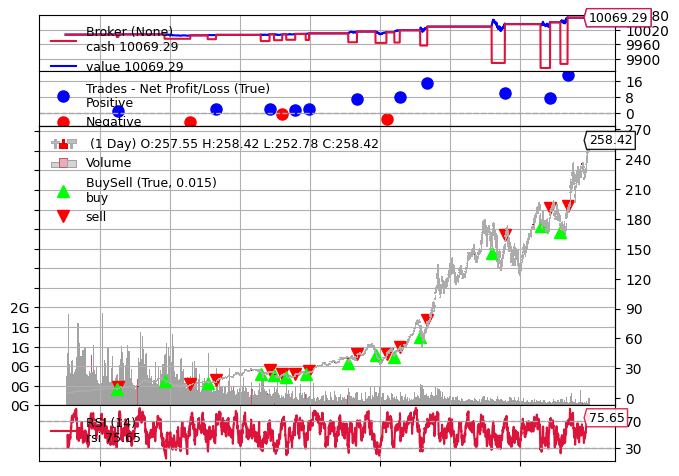

[[<Figure size 640x480 with 5 Axes>]]

In [424]:
cerebro.plot(iplot=False, width=15, height=9)

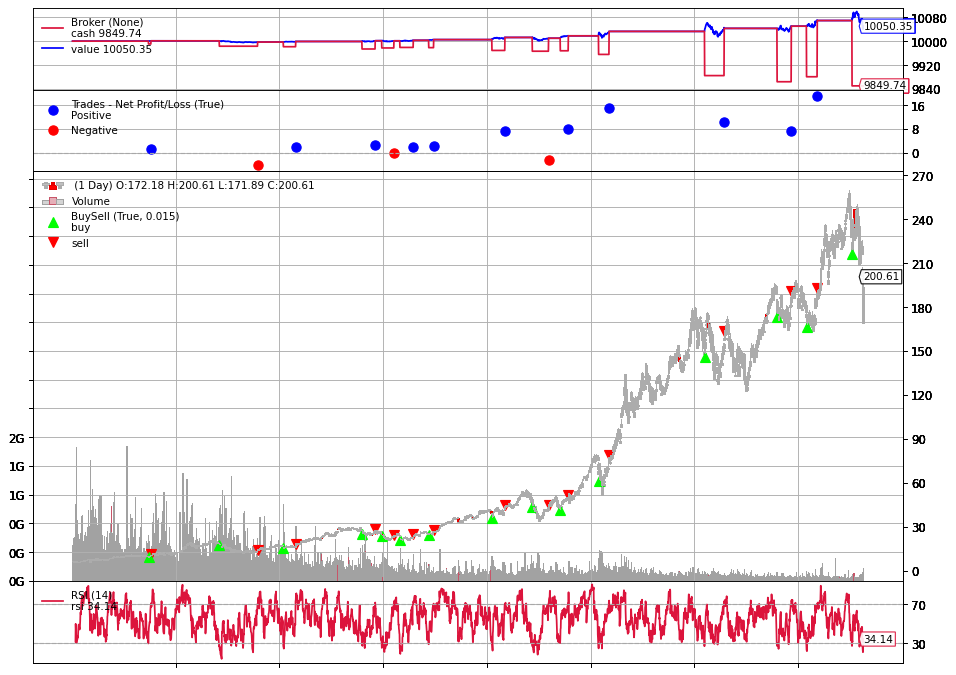

In [425]:
# old saved result
from IPython.display import Image
Image(filename=r"Documents\Backtrader2.PNG")